In [2]:
#loading the annotated data

import scanpy as sc
import pandas as pd
import numpy as np
 
adata = sc.read_h5ad("baseline_annotated.h5ad")

In [3]:
#checking that everything from part 2 came through
#ans: yes, and the numbers represent then number of cells from that patient that fall in that category (responder vs. non-responder)

adata.obs["cell_type"].value_counts()
pd.crosstab(adata.obs["patient"], adata.obs["response"])

response,Non-responder,Responder
patient,,
P1,0,229
P12,330,0
P15,304,0
P2,337,0
P20,323,0
P24,0,338
P25,371,0
P26,0,333
P27,343,0


In [4]:
# Per-patient cell-type fractions: each patient's cells as proportions of their total,
# with their response group attached — ready to compare responders vs non-responders. 


comp = (
    adata.obs
    .groupby("patient")["cell_type"]
    .value_counts(normalize=True)
    .rename("frac")
    .reset_index()
)
resp = adata.obs.drop_duplicates("patient").set_index("patient")["response"]
comp["response"] = comp["patient"].map(resp)
comp

C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\3857733527.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("patient")["cell_type"]


,patient,cell_type,frac,response
0,P1,Exhausted CD8 T cells,0.296943,Responder
1,P1,Naive/stem-like T cells,0.235808,Responder
2,P1,Memory CD8 T cells,0.200873,Responder
3,P1,Cytotoxic CD8 T cells,0.192140,Responder
4,P1,Monocytes/Macrophages,0.030568,Responder
...,...,...,...,...
166,P8,B cells,0.093633,Responder
167,P8,Exhausted CD8 T cells,0.041199,Responder
168,P8,Plasmacytoid dendritic cells,0.011236,Responder
169,P8,Regulatory T cells,0.011236,Responder


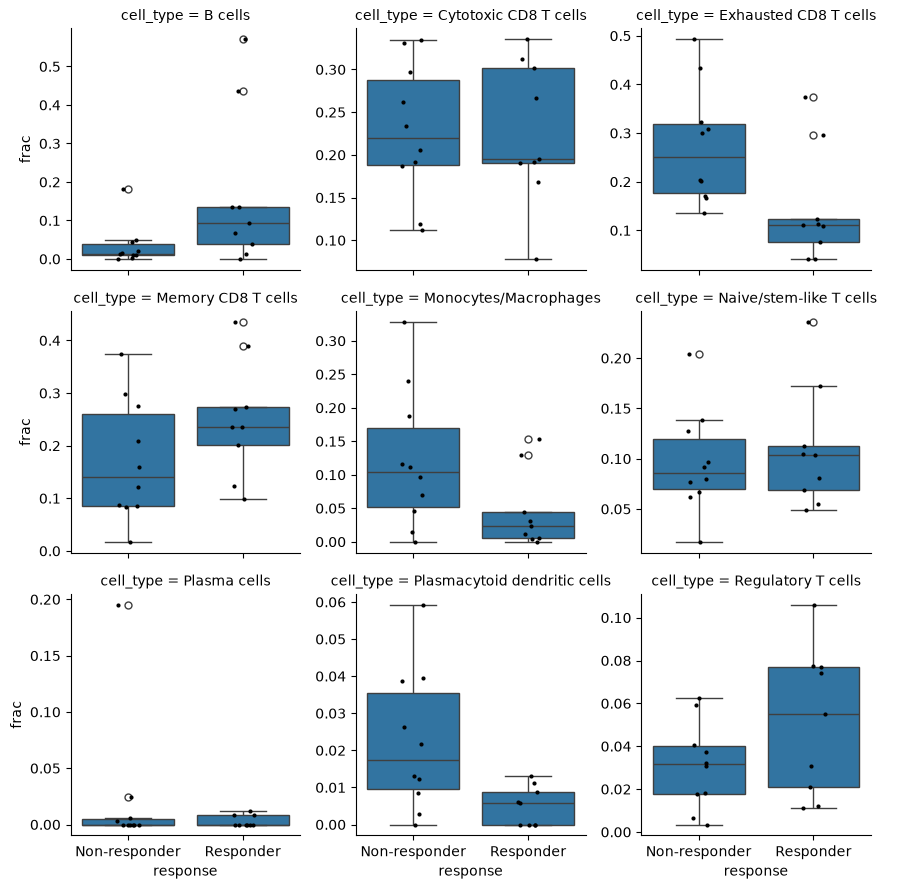

In [5]:
# Box + strip plot of each cell type's fraction, responders vs non-responders —
# box shows the group spread, dots show individual patients (watch for one or two driving a gap). 

import seaborn as sns
g = sns.catplot(
    data=comp, x="response", y="frac", col="cell_type",
    kind="box", col_wrap=3, height=3, sharey=False
)
g.map_dataframe(sns.stripplot, x="response", y="frac", color="black", size=3)

In [6]:
#i want to run scCODA and for that i need to instal pertpy, so i did so in anaconda prompt and here im just checking its worked.

import pertpy as pt
print(pt.__version__)

1.0.3


In [7]:
# Build scCODA's data object: count cells per patient per cell type,
# and attach each patient's response group as the thing to compare.
model = pt.tl.Sccoda()
sccoda_data = model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type",   # my 9 annotated types
    sample_identifier="patient",        # one sample = one patient (n≈19)
    covariate_obs=["response"],         # responders vs non-responders
)

In [8]:
# Set up the model: compare cell-type abundance by response,
# using an auto-picked "steady" cell type as the reference anchor.
sccoda_data = model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="response",
    reference_cell_type="automatic",
)

In [9]:
# Fit the model (Bayesian sampling).
model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:40<00:00, 109.37it/s, 127 steps of size 2.56e-02. acc. prob=0.88]
c:\Users\zoehe\miniconda3\envs\zoe-sc\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [10]:
# Read the verdict: for each cell type, True = a credible change in responders.
model.set_fdr(sccoda_data, 0.2)
model.credible_effects(sccoda_data, modality_key="coda")

Covariate              Cell Type                   
response[T.Responder]  B cells                          True
                       Cytotoxic CD8 T cells           False
                       Exhausted CD8 T cells            True
                       Memory CD8 T cells              False
                       Monocytes/Macrophages            True
                       Naive/stem-like T cells         False
                       Plasma cells                    False
                       Plasmacytoid dendritic cells    False
                       Regulatory T cells              False
Name: Final Parameter, dtype: bool

In [11]:
#Check the reference cell type scCODA auto-picked — everything is measured relative to it, so I should be able to name it

sccoda_data["coda"].uns["scCODA_params"]["reference_cell_type"]


'Regulatory T cells'

In [12]:
# Re-run with an explicit, deliberately-chosen reference to check the result is stable
sccoda_data = model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="response",
    reference_cell_type="Plasma cells",   # a steady, unrelated anchor
)
model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)
model.set_fdr(sccoda_data, 0.2)
model.credible_effects(sccoda_data, modality_key="coda")

sample: 100%|██████████| 11000/11000 [02:02<00:00, 89.49it/s, 127 steps of size 2.27e-02. acc. prob=0.89]


Covariate              Cell Type                   
response[T.Responder]  B cells                          True
                       Cytotoxic CD8 T cells           False
                       Exhausted CD8 T cells            True
                       Memory CD8 T cells              False
                       Monocytes/Macrophages            True
                       Naive/stem-like T cells         False
                       Plasma cells                    False
                       Plasmacytoid dendritic cells    False
                       Regulatory T cells              False
Name: Final Parameter, dtype: bool

In [13]:
#now we are starting differential expresion
#the first step is to pick a cell type 
#in DE we look into which genes differ between responders and non-responders

# Cells per patient per cell type — decides which type keeps enough patients on both sides
counts = pd.crosstab(adata.obs["patient"], adata.obs["cell_type"])
counts

# How many patients clear the 20-cell threshold for each cell type, split by response group
resp = adata.obs.drop_duplicates("patient").set_index("patient")["response"]
(counts >= 20).groupby(resp).sum()

C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\4271640433.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (counts >= 20).groupby(resp).sum()


cell_type,B cells,Cytotoxic CD8 T cells,Exhausted CD8 T cells,Memory CD8 T cells,Monocytes/Macrophages,Naive/stem-like T cells,Plasma cells,Plasmacytoid dendritic cells,Regulatory T cells
response,,,,,,,,,
Non-responder,1,10,10,9,6,9,1,0,1
Responder,5,9,6,9,2,7,0,0,4


In [14]:
# we are choosing Cytotoxic CD8 T cells because they are the only cell type where all 19 patients have >=20 cells,
# so it gives the best-powered responder vs non-responder comparison.

cd8 = adata[adata.obs["cell_type"] == "Cytotoxic CD8 T cells"].copy()

# Work from .raw — the full 55,737 genes on the log2(TPM+1) scale.
# adata.X is scaled HVG data (2,000 genes, centred), which can't be tested for expression.

cd8_raw = cd8.raw.to_adata()
cd8_raw.obs = cd8.obs.copy()
cd8_raw.shape

(1392, 55737)

In [15]:
# Pseudobulk: collapse each patient's cells into one mean profile.
# This is the key step — sample size becomes 19 patients, not ~1,400 cells.
pb = sc.get.aggregate(cd8_raw, by="patient", func="mean")
pb.X = pb.layers["mean"]        # aggregate stores the result in a layer, not X

# Attach each patient's response group
pb.obs["response"] = pb.obs["patient"].map(resp).astype("category")
pb.obs["response"].value_counts()

response
Non-responder    10
Responder         9
Name: count, dtype: int64

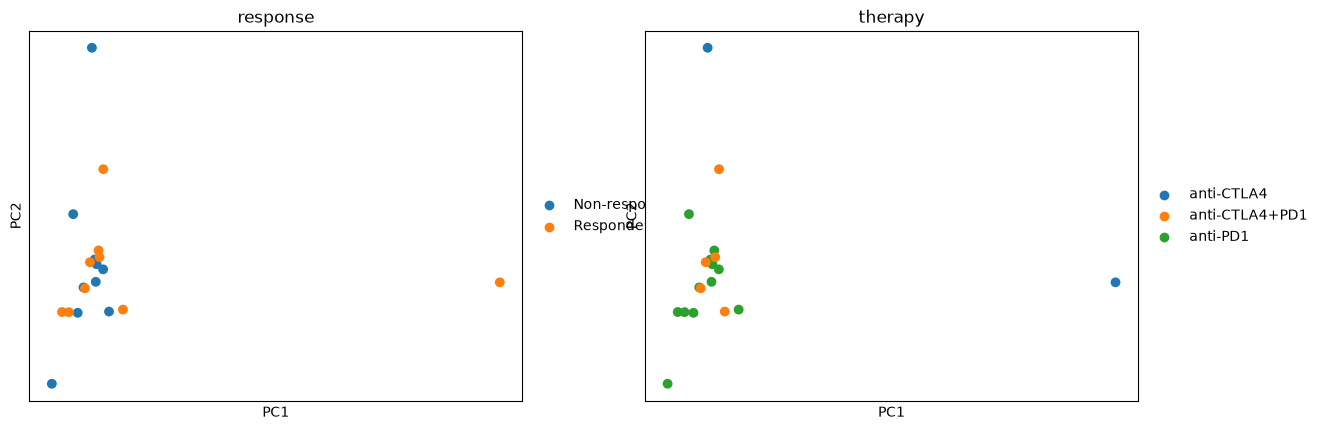

In [16]:
# PCA on the 19 pseudobulk profiles, to see what drives the biggest differences
# between patients before we test anything.
pb_pca = pb.copy()
sc.pp.scale(pb_pca, max_value=10)
sc.tl.pca(pb_pca)

# Attach therapy so we can check whether patients separate by response or by therapy
therapy = adata.obs.drop_duplicates("patient").set_index("patient")["therapy"]
pb_pca.obs["therapy"] = pb_pca.obs["patient"].map(therapy).astype("category")

sc.pl.pca(pb_pca, color=["response", "therapy"], size=200)

In [ ]:
# PCA on pseudobulk profiles — what it showed:
# - No separation by response: responders and non-responders fully intermingled, so no
#   global transcriptome difference. Any real differences will be gene-specific.
# - No separation by therapy: the confound does not dominate the main axis of variation here.
# - One outlier (far right on PC1): the single anti-CTLA4 non-responder. Not removed, but
#   flagged — the per-patient plots will show whether they drive any top hit.

In [17]:
# How many genes survive at different thresholds?
# Rule: a gene must be expressed above `thr` in at least `n` of the 19 patients.
import numpy as np
X = np.asarray(pb.X)

for thr in [0, 0.1, 0.5, 1.0]:
    for n in [5, 10, 15]:
        print(f"thr={thr:<4} in >={n:<3} patients -> {((X > thr).sum(axis=0) >= n).sum():>6} genes")

thr=0    in >=5   patients ->  20769 genes
thr=0    in >=10  patients ->  15580 genes
thr=0    in >=15  patients ->  11995 genes
thr=0.1  in >=5   patients ->  15265 genes
thr=0.1  in >=10  patients ->  12203 genes
thr=0.1  in >=15  patients ->   9748 genes
thr=0.5  in >=5   patients ->   8334 genes
thr=0.5  in >=10  patients ->   6549 genes
thr=0.5  in >=15  patients ->   5004 genes
thr=1.0  in >=5   patients ->   5093 genes
thr=1.0  in >=10  patients ->   3807 genes
thr=1.0  in >=15  patients ->   2714 genes


In [18]:
# Keep genes expressed above 0.5 in at least 10 of 19 patients — drops genes that are
# silent in cytotoxic CD8 cells, so the FDR correction isn't diluted by untestable genes.
keep = (X > 0.5).sum(axis=0) >= 10
pb_f = pb[:, keep].copy()
pb_f.shape

(19, 6549)

In [19]:
# Mann-Whitney per gene across the 19 PATIENTS (not cells) + BH correction.
from scipy.stats import mannwhitneyu, false_discovery_control

Xf = np.asarray(pb_f.X)
is_r = (pb_f.obs["response"] == "Responder").values
r, nr = Xf[is_r], Xf[~is_r]

stat, p = mannwhitneyu(r, nr, axis=0)

# Data is already log2, so the difference of means IS the log2 fold change.
lfc = r.mean(axis=0) - nr.mean(axis=0)

res = pd.DataFrame({
    "gene": pb_f.var_names,
    "log2FC": lfc,
    "p": p,
    "FDR": false_discovery_control(p, method="bh"),
}).sort_values("p")

res.head(20)

,gene,log2FC,p,FDR
3834,PTMS,-0.686422,0.000517,0.330953
3264,ENSA,-1.123067,0.000520,0.330953
4983,PRF1,-3.189904,0.000520,0.330953
1465,FTSJ3,-0.483909,0.000703,0.330953
933,FBXO7,-1.142974,0.000703,0.330953
549,TTC38,-0.737160,0.000944,0.330953
3668,BUB3,-1.230059,0.000944,0.330953
134,CAPN1,-0.794983,0.000944,0.330953
5686,GPR56,-1.469835,0.000944,0.330953
6039,HLA-DPA1,-2.316350,0.000944,0.330953


In [20]:
# Are the top hits real, or is there a global shift between the groups?
print("median log2FC across ALL tested genes:", np.median(res["log2FC"]))
print("fraction of genes negative:", (res["log2FC"] < 0).mean().round(3))

# Genes detected per cell, per group — a proxy for depth differences
pb_f.obs["n_genes"] = adata.obs.groupby("patient")["n_genes_by_counts"].mean().reindex(pb_f.obs["patient"]).values
pb_f.obs.groupby("response")["n_genes"].mean()

median log2FC across ALL tested genes: -0.1229494573079789
fraction of genes negative: 0.694


C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\4211147702.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb_f.obs["n_genes"] = adata.obs.groupby("patient")["n_genes_by_counts"].mean().reindex(pb_f.obs["patient"]).values
C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\4211147702.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb_f.obs.groupby("response")["n_genes"].mean()


response
Non-responder    2394.490033
Responder        2032.639337
Name: n_genes, dtype: float64

In [21]:
# Centre each patient's profile on its own median, removing the global depth shift
# so genes are compared on relative, not absolute, level.
Xc = Xf - np.median(Xf, axis=1, keepdims=True)

stat_c, p_c = mannwhitneyu(Xc[is_r], Xc[~is_r], axis=0)
lfc_c = Xc[is_r].mean(axis=0) - Xc[~is_r].mean(axis=0)

res_c = pd.DataFrame({
    "gene": pb_f.var_names, "log2FC": lfc_c, "p": p_c,
    "FDR": false_discovery_control(p_c, method="bh"),
}).sort_values("p")

print("median log2FC now:", np.median(res_c["log2FC"]).round(4))
print("fraction negative:", (res_c["log2FC"] < 0).mean().round(3))
res_c.head(20)

median log2FC now: 0.0113
fraction negative: 0.483


,gene,log2FC,p,FDR
3264,ENSA,-0.988858,0.000520,0.345158
1029,PSMA6,-1.427022,0.000703,0.345158
933,FBXO7,-1.008765,0.000703,0.345158
3668,BUB3,-1.095850,0.000944,0.345158
1833,PASK,0.783534,0.000944,0.345158
3381,PAM,-1.004322,0.000944,0.345158
1311,KXD1,-0.845502,0.001259,0.345158
5406,CASP4,-0.927720,0.001259,0.345158
2684,ARL8B,-0.776670,0.001259,0.345158
1773,FOXP1,1.038463,0.001259,0.345158


In [23]:
import matplotlib.pyplot as plt

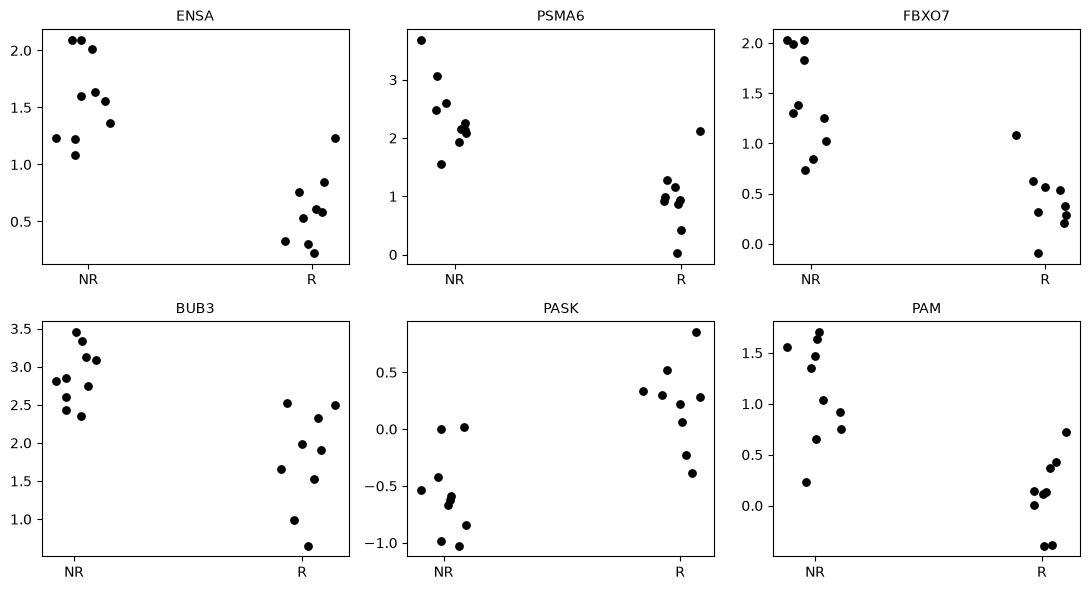

In [24]:
# Top hits, one dot per patient — does the difference hold across most patients,
# or is it driven by one or two? Plotted on the centred values the test used.
top = res_c["gene"].head(6).tolist()
idx = [list(pb_f.var_names).index(g) for g in top]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, g, i in zip(axes.flat, top, idx):
    for j, grp in enumerate(["Non-responder", "Responder"]):
        m = (pb_f.obs["response"] == grp).values
        ax.scatter(np.random.normal(j, 0.06, m.sum()), Xc[m, i], s=28, color="black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["NR", "R"])
    ax.set_title(g, fontsize=10)
plt.tight_layout()

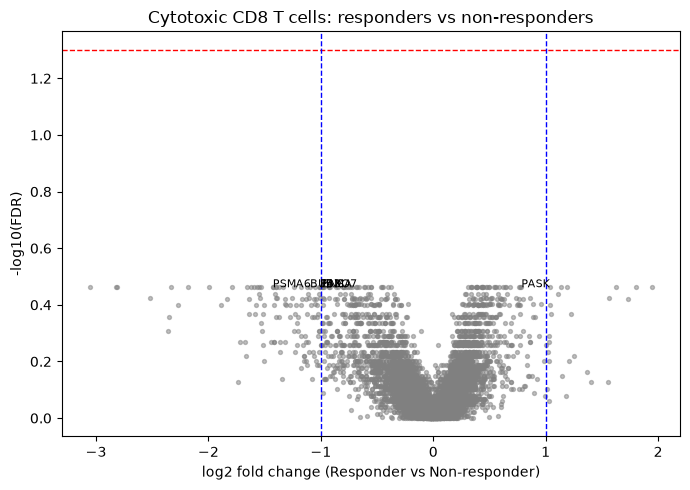

In [25]:
# Volcano plot: x = log2 fold change, y = -log10(FDR).
# A hit needs BOTH a low FDR and a meaningful fold change.
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(res_c["log2FC"], -np.log10(res_c["FDR"]), s=8, color="grey", alpha=0.5)

ax.axhline(-np.log10(0.05), ls="--", lw=1, color="red")     # FDR = 0.05
ax.axvline(1, ls="--", lw=1, color="blue")                  # 2-fold up
ax.axvline(-1, ls="--", lw=1, color="blue")                 # 2-fold down

# Label the top few genes
for _, row in res_c.head(6).iterrows():
    ax.text(row["log2FC"], -np.log10(row["FDR"]), row["gene"], fontsize=8)

ax.set_xlabel("log2 fold change (Responder vs Non-responder)")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Cytotoxic CD8 T cells: responders vs non-responders")
plt.tight_layout()

In [26]:
# Therapy confound check: recompute fold changes using ONLY anti-PD1 patients.
# 8 NR vs 4 R is far too small for p-values — this compares DIRECTION and effect size.
pb_f.obs["therapy"] = pb_f.obs["patient"].map(therapy).values
pd1 = (pb_f.obs["therapy"] == "anti-PD1").values

r_pd1 = pd1 & is_r
nr_pd1 = pd1 & ~is_r
print("anti-PD1 patients:", nr_pd1.sum(), "NR vs", r_pd1.sum(), "R")

lfc_pd1 = Xc[r_pd1].mean(axis=0) - Xc[nr_pd1].mean(axis=0)

check = res_c.head(15).copy()
gene_idx = [list(pb_f.var_names).index(g) for g in check["gene"]]
check["log2FC_antiPD1"] = lfc_pd1[gene_idx]
check["same_direction"] = np.sign(check["log2FC"]) == np.sign(check["log2FC_antiPD1"])
check[["gene", "log2FC", "log2FC_antiPD1", "same_direction"]]

anti-PD1 patients: 8 NR vs 4 R


,gene,log2FC,log2FC_antiPD1,same_direction
3264,ENSA,-0.988858,-1.136215,True
1029,PSMA6,-1.427022,-1.359858,True
933,FBXO7,-1.008765,-1.030549,True
3668,BUB3,-1.095850,-1.411790,True
1833,PASK,0.783534,0.994540,True
3381,PAM,-1.004322,-0.991419,True
1311,KXD1,-0.845502,-0.709963,True
5406,CASP4,-0.927720,-0.960658,True
2684,ARL8B,-0.776670,-0.912519,True
1773,FOXP1,1.038463,1.234711,True


In [27]:
# Signature scoring: score each cell for a whole programme, then average per patient.
# Gene lists are from the supervisor's sheet.
sigs = {
    "cytotoxicity": ["GZMB", "PRF1", "GNLY", "NKG7", "IFNG"],
    "exhaustion":   ["PDCD1", "HAVCR2", "LAG3", "TIGIT", "CTLA4", "TOX"],
    "memory_stem":  ["TCF7", "IL7R", "CCR7", "SELL"],
}

for name, genes in sigs.items():
    sc.tl.score_genes(adata, genes, score_name=name, use_raw=True)

In [28]:
# Per-patient mean score within cytotoxic CD8 cells only, so differences reflect
# cell STATE rather than differences in cell-type composition.
sub = adata.obs[adata.obs["cell_type"] == "Cytotoxic CD8 T cells"]
scores = sub.groupby("patient")[list(sigs)].mean()
scores["response"] = scores.index.map(resp)

for name in sigs:
    r = scores.loc[scores["response"] == "Responder", name]
    nr = scores.loc[scores["response"] == "Non-responder", name]
    u, p = mannwhitneyu(r, nr)
    print(f"{name:14} R={r.mean():+.3f}  NR={nr.mean():+.3f}  diff={r.mean()-nr.mean():+.3f}  p={p:.4f}")

cytotoxicity   R=-0.223  NR=+1.645  diff=-1.868  p=0.0062
exhaustion     R=-0.213  NR=+0.949  diff=-1.162  p=0.0101
memory_stem    R=+0.091  NR=-1.596  diff=+1.687  p=0.0017


C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\3142208942.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores = sub.groupby("patient")[list(sigs)].mean()


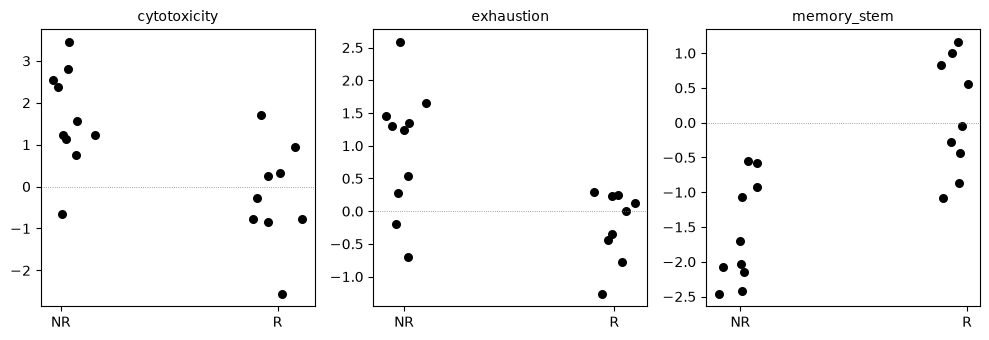

In [29]:
# One dot per patient for each signature score — does the difference hold across
# most patients, or is it a couple of people doing the work?
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, name in zip(axes, sigs):
    for j, grp in enumerate(["Non-responder", "Responder"]):
        vals = scores.loc[scores["response"] == grp, name]
        ax.scatter(np.random.normal(j, 0.06, len(vals)), vals, s=30, color="black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["NR", "R"])
    ax.axhline(0, lw=0.6, color="grey", ls=":")
    ax.set_title(name, fontsize=10)
plt.tight_layout()

In [30]:
# Therapy confound check: anti-PD1 patients only (8 NR vs 4 R).
scores["therapy"] = scores.index.map(therapy)
pd1_only = scores[scores["therapy"] == "anti-PD1"]

for name in sigs:
    r = pd1_only.loc[pd1_only["response"] == "Responder", name]
    nr = pd1_only.loc[pd1_only["response"] == "Non-responder", name]
    u, p = mannwhitneyu(r, nr)
    print(f"{name:14} R={r.mean():+.3f}  NR={nr.mean():+.3f}  diff={r.mean()-nr.mean():+.3f}  p={p:.4f}")

cytotoxicity   R=-0.522  NR=+1.819  diff=-2.341  p=0.0040
exhaustion     R=-0.092  NR=+0.952  diff=-1.044  p=0.1535
memory_stem    R=-0.269  NR=-1.649  diff=+1.379  p=0.0727


In [31]:
# Alternative pseudobulk (supervisor's suggestion): average TPM values, then log —
# instead of averaging the logged values. Less sensitive to dropout zeros.
cd8_tpm = cd8_raw.copy()
cd8_tpm.X.data = 2**cd8_tpm.X.data - 1                  # undo log2 -> back to TPM

pb2 = sc.get.aggregate(cd8_tpm, by="patient", func="mean")
pb2.X = np.log2(np.asarray(pb2.layers["mean"]) + 1)     # average, then re-log
pb2.obs["response"] = pb2.obs["patient"].map(resp).astype("category")

# Same gene filter as before, for a fair comparison
X2 = np.asarray(pb2.X)
keep2 = (X2 > 0.5).sum(axis=0) >= 10
pb2_f = pb2[:, keep2].copy()
print(pb2_f.shape)

(19, 12844)


In [32]:
# Does this aggregation still show the global shift? (No centring applied.)
X2f = np.asarray(pb2_f.X)
is_r2 = (pb2_f.obs["response"] == "Responder").values

stat2, p2 = mannwhitneyu(X2f[is_r2], X2f[~is_r2], axis=0)
lfc2 = X2f[is_r2].mean(axis=0) - X2f[~is_r2].mean(axis=0)

res2 = pd.DataFrame({
    "gene": pb2_f.var_names, "log2FC": lfc2, "p": p2,
    "FDR": false_discovery_control(p2, method="bh"),
}).sort_values("p")

print("median log2FC:", np.median(res2["log2FC"]).round(4))
print("fraction negative:", (res2["log2FC"] < 0).mean().round(3))
res2.head(20)

median log2FC: -0.0501
fraction negative: 0.541


,gene,log2FC,p,FDR
5202,ARNT,-1.397156,0.000280,0.75053
2307,FTSJ3,-1.119944,0.000280,0.75053
11880,FDXACB1,2.710245,0.000360,0.75053
2326,MRPL27,-2.273161,0.000380,0.75053
4694,CCBL2,1.600555,0.000383,0.75053
2685,SUB1,-0.546265,0.000520,0.75053
1543,CDKN3,-2.955098,0.000699,0.75053
1597,PSMA6,-0.906056,0.000703,0.75053
8644,SERINC4,1.466280,0.000939,0.75053
4268,ARL8B,-1.366282,0.000944,0.75053


In [ ]:
# Do the exhaustion/activation genes she named stand out under this aggregation?

# Result: all nine exhaustion/cytotoxicity genes are negative (higher in non-responders),
# with CD38, HAVCR2, LAG3, PRF1 and GZMB showing decent effect sizes and raw p < 0.05.
# Important cross-check: PRF1 and GZMB are back under this aggregation, and they are the same
# genes that drove the cytotoxicity signature score — so this agrees with the signature result,
# whereas the centred version removed PRF1 entirely. Evidence that centring over-corrected.
# Caveat 1: still nothing significant (FDR 0.75) — the coherent pattern is the finding, not any single gene.
# Caveat 2: no sign test on "9 out of 9 negative" — these genes are co-expressed as a module, so they
# are not independent, and the whole dataset already runs 54% negative. Suggestive, not quantifiable.
# This is what enrichment is designed to test properly: the programme as a set, not gene by gene.
targets = ["CD38", "HAVCR2", "LAG3", "PDCD1", "TIGIT", "TOX", "CTLA4", "GZMB", "PRF1"]
res2[res2["gene"].isin(targets)][["gene", "log2FC", "p", "FDR"]]

,gene,log2FC,p,FDR
32,CD38,-1.859980,0.001259,0.750530
8319,PRF1,-1.558462,0.002200,0.750530
1530,GZMB,-2.529054,0.010112,0.750530
4362,HAVCR2,-1.929768,0.030486,0.767278
1220,LAG3,-1.114825,0.037336,0.767278
8960,PDCD1,-0.839566,0.055014,0.787734
8394,TIGIT,-0.510609,0.347746,0.932452
6597,CTLA4,-1.047189,0.391267,0.934791
9496,TOX,-0.104776,0.775051,0.986988


In [ ]:
# Which cell types have enough patients on BOTH sides at the sheet's lower bound (10 cells)?

# Result at the 10-cell threshold (the sheet's lower bound):
# Viable for DE — enough patients on both sides:
#   Exhausted CD8 10/9  ·  Memory CD8 9/9  ·  Naive/stem-like 9/8
#   (Exhausted CD8 was only 10/6 at 20 cells, so lowering the threshold makes it usable.)
# Marginal / exploratory only:
#   Regulatory T 6/4  ·  Monocytes/Macrophages 8/3  ·  B cells 3/7
# Not possible: Plasma 1/0, pDC 3/0.
#
# So B cells, myeloid and Tregs cannot properly support differential expression here — too few
# patients have enough cells. Note this is a limitation of EXPRESSION testing only: the composition
# analysis did find B cells and Monocytes credible, and the paper's signal in those compartments
# was compositional rather than gene-level.
#
# Trade-off of using 10 instead of 20 cells: per-patient averages are noisier, since some patients
# contribute an average of only ~10 cells. This is the price of including Exhausted CD8.
(counts >= 10).groupby(resp).sum()

C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\1019258805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (counts >= 10).groupby(resp).sum()


cell_type,B cells,Cytotoxic CD8 T cells,Exhausted CD8 T cells,Memory CD8 T cells,Monocytes/Macrophages,Naive/stem-like T cells,Plasma cells,Plasmacytoid dendritic cells,Regulatory T cells
response,,,,,,,,,
Non-responder,3,10,10,9,8,9,1,3,6
Responder,7,9,9,9,3,8,0,0,4


In [35]:
# Wraps the DE pipeline (already run on cytotoxic CD8) into one reusable function,
# using the TPM-first aggregation. No centring — that step is dropped per supervisor feedback.
import scipy.sparse as sp

def run_de(cell_type, min_cells=10, thr=0.5, min_pat=10):
    sub = adata[adata.obs["cell_type"] == cell_type]

    # keep only patients with enough cells of this type
    n = sub.obs["patient"].value_counts()
    ok = n[n >= min_cells].index
    sub = sub[sub.obs["patient"].isin(ok)].copy()

    # full genes on the log2(TPM+1) scale, then undo the log to get TPM
    raw = sub.raw.to_adata()
    raw.obs = sub.obs.copy()
    if sp.issparse(raw.X):
        raw.X = raw.X.copy(); raw.X.data = 2**raw.X.data - 1
    else:
        raw.X = 2**raw.X - 1

    # average TPM per patient, then re-log
    pbx = sc.get.aggregate(raw, by="patient", func="mean")
    pbx.X = np.log2(np.asarray(pbx.layers["mean"]) + 1)
    grp = pbx.obs["patient"].map(resp).values

    # same gene filter as before
    M = np.asarray(pbx.X)
    keep = (M > thr).sum(axis=0) >= min_pat
    M, genes = M[:, keep], pbx.var_names[keep]

    r = grp == "Responder"
    stat, p = mannwhitneyu(M[r], M[~r], axis=0)

    out = pd.DataFrame({
        "gene": genes,
        "log2FC": M[r].mean(axis=0) - M[~r].mean(axis=0),
        "p": p,
        "FDR": false_discovery_control(p, method="bh"),
    }).sort_values("p")

    print(f"{cell_type}: {(~r).sum()} NR vs {r.sum()} R  |  {keep.sum()} genes  "
          f"|  median log2FC {np.median(out['log2FC']):+.3f}  "
          f"|  {(out['log2FC']<0).mean():.0%} negative  |  best FDR {out['FDR'].min():.3f}")
    return out

In [36]:
# Check the function reproduces the cytotoxic CD8 result we already computed
res_check = run_de("Cytotoxic CD8 T cells", min_cells=20)
res_check.head(10)

Cytotoxic CD8 T cells: 10 NR vs 9 R  |  12844 genes  |  median log2FC -0.050  |  54% negative  |  best FDR 0.751


,gene,log2FC,p,FDR
5202,ARNT,-1.397156,0.000280,0.75053
2307,FTSJ3,-1.119944,0.000280,0.75053
11880,FDXACB1,2.710245,0.000360,0.75053
2326,MRPL27,-2.273161,0.000380,0.75053
4694,CCBL2,1.600555,0.000383,0.75053
2685,SUB1,-0.546265,0.000520,0.75053
1543,CDKN3,-2.955098,0.000699,0.75053
1597,PSMA6,-0.906056,0.000703,0.75053
8644,SERINC4,1.466280,0.000939,0.75053
4268,ARL8B,-1.366282,0.000944,0.75053


In [37]:
# Run the same pipeline on the other viable cell types (10-cell threshold).
results = {}
for ct in ["Exhausted CD8 T cells", "Memory CD8 T cells", "Naive/stem-like T cells"]:
    results[ct] = run_de(ct, min_cells=10)

Exhausted CD8 T cells: 10 NR vs 9 R  |  12847 genes  |  median log2FC -0.229  |  68% negative  |  best FDR 0.682
Memory CD8 T cells: 9 NR vs 9 R  |  11964 genes  |  median log2FC +0.067  |  45% negative  |  best FDR 0.796
Naive/stem-like T cells: 9 NR vs 8 R  |  10306 genes  |  median log2FC -0.089  |  56% negative  |  best FDR 0.910


In [38]:
# Tregs — exploratory only (6 NR vs 4 R), included because the supervisor asked.
results["Regulatory T cells"] = run_de("Regulatory T cells", min_cells=10)

Regulatory T cells: 6 NR vs 4 R  |  3130 genes  |  median log2FC +0.070  |  45% negative  |  best FDR 0.590


In [ ]:
# Is the shift in Exhausted CD8 a depth difference, or biology?

# Result: non-responders 2,706 genes/cell vs responders 2,342 — about 15.5% more detected,
# so a depth difference exists in Exhausted CD8 too.
# But the comparison with Cytotoxic CD8 is what matters: there the depth gap was LARGER (~18%)
# yet the residual shift was much smaller (median log2FC -0.050 vs -0.229 here).
# Under the same TPM-first aggregation, Exhausted CD8 stays strongly lopsided (68% negative).
# So the shift here is probably NOT purely technical — if depth were the whole story, a smaller
# depth gap should give a smaller shift, not a four-times-larger one. Likely a real biological
# component: exhausted cells in non-responders being more transcriptionally active.
# This fits the other results — non-responders have more exhausted cells (composition) and higher
# exhaustion scores (signatures), so a more activated exhausted compartment is consistent.
# Limits: detection and transcriptional activity are entangled (more active cells genuinely detect
# more genes), and this is a comparison between two cell types, not a controlled test.
# Present as suggestive, and worth the supervisor's view — not a conclusion.


ex = adata.obs[adata.obs["cell_type"] == "Exhausted CD8 T cells"]
per_pat = ex.groupby("patient")["n_genes_by_counts"].mean()
n_ex = ex["patient"].value_counts()
keep_pat = n_ex[n_ex >= 10].index
tmp = pd.DataFrame({"n_genes": per_pat[keep_pat], "response": resp[keep_pat]})
print(tmp.groupby("response")["n_genes"].mean())

response
Non-responder    2705.685456
Responder        2341.826518
Name: n_genes, dtype: float64


C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\1803663509.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pat = ex.groupby("patient")["n_genes_by_counts"].mean()
C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\1803663509.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tmp.groupby("response")["n_genes"].mean())


In [ ]:
# What tops the Exhausted CD8 ranking?

# Top 15 in Exhausted CD8 — inconclusive, doesn't settle the biology-vs-artefact question.
# - Not an exhaustion signature: no PDCD1, LAG3, HAVCR2, TOX.
# - But not obviously technical either: a depth artefact usually pushes ribosomal/mitochondrial
#   genes to the top, and those aren't here (RRS1 = ribosome biogenesis, MT1E = metallothionein).
# - 13/15 negative, consistent with the 68% overall shift.
# - Two lncRNAs (RP11-...) in the top 15 is a mild noise flag — low expression, unstable.
# - Nothing significant: FDR 0.68 throughout.
# Conclusion: eyeballing the top genes doesn't settle it. Check the named exhaustion genes
# directly instead, then use enrichment to test whole programmes properly.
results["Exhausted CD8 T cells"].head(15)

,gene,log2FC,p,FDR
10104,LCAT,-2.469814,0.000194,0.682201
8281,MSC,-3.638115,0.000194,0.682201
8305,RRS1,-2.005985,0.000383,0.682201
4472,PCNXL2,1.240035,0.000520,0.682201
12000,RP11-809N8.2,-1.210946,0.000520,0.682201
1570,ITPK1,-1.535564,0.000520,0.682201
2407,LRP2BP,-1.641581,0.000629,0.682201
12310,RP11-252K23.2,-1.773369,0.000651,0.682201
7447,MT1E,-2.030925,0.000699,0.682201
3883,FAM64A,-2.745997,0.001139,0.682201


In [ ]:
# Do the exhaustion genes stand out in the Exhausted CD8 compartment itself?

# Exhaustion markers in Exhausted CD8 are essentially FLAT: PDCD1 -0.12, TIGIT +0.09,
# TOX +0.11, CTLA4 +0.14 — four of them point opposite to the overall negative shift.
# So the cells labelled exhausted are equally exhausted in BOTH groups.
# What differs is cytotoxic machinery: GZMB -2.23, PRF1 -0.90 (both p=0.037), CD38 -1.11.
# This supports the composition finding: the difference between groups is HOW MANY exhausted
# cells a patient has, not how exhausted those cells are.
# It also weakens the biological reading of the 68% global shift — if that shift were an
# exhaustion programme, these markers would show it, and they don't.
# GZMB/PRF1 topping both CD8 compartments is the most consistent gene-level signal so far.


ex_res = results["Exhausted CD8 T cells"]
ex_res[ex_res["gene"].isin(targets)][["gene", "log2FC", "p", "FDR"]]


,gene,log2FC,p,FDR
1541,GZMB,-2.225288,0.037336,0.682201
8400,PRF1,-0.897448,0.037336,0.682201
32,CD38,-1.108455,0.094166,0.710785
4398,HAVCR2,-0.409573,0.177910,0.759842
1233,LAG3,-0.534806,0.487668,0.910357
9059,PDCD1,-0.118773,0.775051,0.966801
6643,CTLA4,0.140504,0.838256,0.979185
9603,TOX,0.114436,0.902523,0.988888
8478,TIGIT,0.090480,0.902523,0.988888


In [ ]:
# Signature scores in the other cell types, using the same 10-cell patient threshold.
# 3 programmes x 4 cell types = 12 tests, so p-values are BH-corrected across all of them.

# Signature scores across 4 CD8 cell types (12 tests, BH-corrected):
# - memory/stem-like is SIGNIFICANT IN ALL FOUR cell types, always higher in responders.
#   Strongest and most reproducible finding in the project.
# - Direction is 100% consistent across all 12 tests: cytotoxicity lower in responders,
#   exhaustion lower, stem-like higher. No exceptions.
# - 9 of 12 survive FDR 0.05. The three that don't: cytotoxicity in Exhausted CD8 (0.103)
#   and Naive (0.089), exhaustion in Exhausted CD8 (0.206).
# - Exhaustion is FLAT in Exhausted CD8 (diff -0.56, FDR 0.21) — matches the flat PDCD1/TOX/
#   TIGIT markers from the DE run. Two independent analyses agreeing.
#
# Caveats:
# - The 12 tests are NOT independent: same patients, overlapping cells, and the three
#   signatures are biologically correlated. BH assumes more independence than we have.
# - Partial circularity: cell types were annotated using some of these same marker genes
#   (TCF7/IL7R/CCR7/SELL define naive/stem-like). The responder vs non-responder comparison
#   is still made WITHIN each cell type, which limits this, but it should be stated.

rows = []
for ct in ["Cytotoxic CD8 T cells", "Exhausted CD8 T cells",
           "Memory CD8 T cells", "Naive/stem-like T cells"]:
    s = adata.obs[adata.obs["cell_type"] == ct]
    n = s["patient"].value_counts()
    s = s[s["patient"].isin(n[n >= 10].index)]

    sc_pat = s.groupby("patient")[list(sigs)].mean().dropna()
    grp = sc_pat.index.map(resp)

    for name in sigs:
        r = sc_pat.loc[grp == "Responder", name]
        nr = sc_pat.loc[grp == "Non-responder", name]
        u, p = mannwhitneyu(r, nr)
        rows.append({"cell_type": ct, "signature": name,
                     "n_NR": len(nr), "n_R": len(r),
                     "R": r.mean(), "NR": nr.mean(),
                     "diff": r.mean() - nr.mean(), "p": p})

sig_res = pd.DataFrame(rows)
sig_res["FDR"] = false_discovery_control(sig_res["p"], method="bh")
sig_res.round(4)

C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\2629653358.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sc_pat = s.groupby("patient")[list(sigs)].mean().dropna()
C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\2629653358.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sc_pat = s.groupby("patient")[list(sigs)].mean().dropna()
C:\Users\zoehe\AppData\Local\Temp\ipykernel_16360\2629653358.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

,cell_type,signature,n_NR,n_R,R,NR,diff,p,FDR
0,Cytotoxic CD8 T cells,cytotoxicity,10,9,-0.2227,1.6452,-1.8679,0.0062,0.0125
1,Cytotoxic CD8 T cells,exhaustion,10,9,-0.2133,0.9488,-1.1620,0.0101,0.0173
2,Cytotoxic CD8 T cells,memory_stem,10,9,0.0913,-1.5960,1.6873,0.0017,0.0125
3,Exhausted CD8 T cells,cytotoxicity,10,9,-0.1513,1.2438,-1.3952,0.0942,0.1027
4,Exhausted CD8 T cells,exhaustion,10,9,1.2233,1.7871,-0.5638,0.2057,0.2057
5,Exhausted CD8 T cells,memory_stem,10,9,-1.3858,-2.5825,1.1967,0.0128,0.0191
6,Memory CD8 T cells,cytotoxicity,9,9,-1.0667,0.7350,-1.8017,0.0036,0.0125
7,Memory CD8 T cells,exhaustion,9,9,-0.7044,0.2931,-0.9975,0.0171,0.0228
8,Memory CD8 T cells,memory_stem,9,9,1.0671,-0.6978,1.7649,0.0062,0.0125
9,Naive/stem-like T cells,cytotoxicity,9,8,0.5012,2.0393,-1.5381,0.0745,0.0893


In [ ]:
#now i am starting the enrichment process

# Confirm gseapy installed correctly
import gseapy
print(gseapy.__version__)

1.3.0


In [44]:
# Add cytotoxic CD8 to the results dict so all five are in one place
results["Cytotoxic CD8 T cells"] = res_check

In [45]:
# GSEA prerank: rank ALL genes by effect size and ask which pathways sit at the top/bottom.
# No significance cutoff needed — which is why it works when nothing passed FDR.
# Negative log2FC = higher in non-responders.
rnk = (results["Cytotoxic CD8 T cells"][["gene", "log2FC"]]
       .dropna().sort_values("log2FC", ascending=False))

pre = gseapy.prerank(
    rnk=rnk,
    gene_sets="MSigDB_Hallmark_2020",   # needs internet
    permutation_num=1000,
    seed=42,
    min_size=10,
    max_size=500,
    outdir=None,
)

out = pre.res2d[["Term", "NES", "NOM p-val", "FDR q-val"]].copy()
out = out.sort_values("NES")
out.head(10)      # most enriched in NON-RESPONDERS

2026-07-21 13:41:34,705 [WARNING] Duplicated values found in preranked stats: 0.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,NOM p-val,FDR q-val
0,Interferon Alpha Response,-2.121674,0.000000,0.000000
1,Interferon Gamma Response,-2.090995,0.000000,0.000000
2,E2F Targets,-1.826930,0.000000,0.003176
3,Cholesterol Homeostasis,-1.817573,0.000000,0.002680
4,mTORC1 Signaling,-1.753460,0.000000,0.006670
5,G2-M Checkpoint,-1.735651,0.000000,0.006352
6,Pperoxisome,-1.698352,0.000000,0.009018
7,Oxidative Phosphorylation,-1.492920,0.003866,0.078608
8,Glycolysis,-1.439625,0.017711,0.115927
9,Hypoxia,-1.417461,0.021097,0.126964


In [ ]:
out.tail(10)      # most enriched in RESPONDERS


# GSEA (Hallmark) on Cytotoxic CD8 — the first significant result of the DE arm.
# Enriched in NON-RESPONDERS:
#   Interferon Alpha Response  NES -2.12, FDR ~0.000
#   Interferon Gamma Response  NES -2.09, FDR ~0.000
#   E2F Targets -1.83, Cholesterol Homeostasis -1.82, mTORC1 -1.75,
#   G2-M Checkpoint -1.74, Peroxisome -1.70  (all FDR < 0.01)
# Enriched in RESPONDERS: nothing significant (best FDR 0.66, Wnt-beta Catenin).
#
# Why this worked when gene-by-gene did not: 50 gene sets instead of 12,844 genes, and
# pooling many weakly-shifted genes into one score. The signal was there, it just could not
# clear a 12,844-way correction.
# Biological reading: non-responders' cytotoxic CD8 cells show an interferon-driven, activated,
# proliferating, metabolically engaged state — consistent with the signature scoring
# (higher cytotoxicity and exhaustion in NR) and with the composition result.
#
# Caveat to state: ALL significant terms are on the non-responder side, nothing on the responder
# side. Expected if NR cells are genuinely more active, but also what a residual global shift
# would produce (ranking still runs 54% negative, median -0.05). The specificity of interferon
# (well ahead of everything else) argues it is real, but this should be stated, not glossed.
# Note: gseapy warned that 0.13% of genes had duplicate ranking values — negligible.

,Term,NES,NOM p-val,FDR q-val
44,Apical Junction,-0.811808,0.822604,0.851854
48,PI3K/AKT/mTOR Signaling,-0.661006,0.987395,0.977196
47,Pancreas Beta Cells,0.683860,0.857143,0.973381
46,Coagulation,0.767514,0.894587,1.000000
45,heme Metabolism,0.776543,0.971074,1.000000
43,Androgen Response,0.814368,0.863492,1.000000
42,KRAS Signaling Up,0.865022,0.747604,1.000000
38,Hedgehog Signaling,0.907778,0.586124,1.000000
36,Myogenesis,0.981561,0.476974,1.000000
17,Wnt-beta Catenin Signaling,1.273260,0.135338,0.663008


In [47]:
# Same GSEA across the other cell types — does the interferon signal reproduce?
gsea_all = {}
for ct in ["Exhausted CD8 T cells", "Memory CD8 T cells", "Naive/stem-like T cells"]:
    rnk_ct = (results[ct][["gene", "log2FC"]].dropna()
              .sort_values("log2FC", ascending=False))
    pre_ct = gseapy.prerank(rnk=rnk_ct, gene_sets="MSigDB_Hallmark_2020",
                            permutation_num=1000, seed=42,
                            min_size=10, max_size=500, outdir=None)
    gsea_all[ct] = pre_ct.res2d[["Term", "NES", "NOM p-val", "FDR q-val"]]
    print(f"\n=== {ct} ===")
    print(gsea_all[ct].sort_values("NES").head(6).to_string(index=False))

2026-07-21 13:45:46,099 [WARNING] Duplicated values found in preranked stats: 0.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-21 13:45:49,086 [WARNING] Duplicated values found in preranked stats: 0.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



=== Exhausted CD8 T cells ===
                  Term       NES  NOM p-val  FDR q-val
           E2F Targets -1.773512   0.000000   0.004109
       G2-M Checkpoint -1.731516   0.000000   0.003595
Estrogen Response Late -1.532978   0.000000   0.041088
           Pperoxisome -1.496428   0.003033   0.055469
       Mitotic Spindle -1.478113   0.001002   0.060195
  Bile Acid Metabolism -1.446546   0.010256   0.069508


2026-07-21 13:45:52,178 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



=== Memory CD8 T cells ===
                     Term       NES  NOM p-val  FDR q-val
Interferon Gamma Response -2.448056   0.000000   0.000000
Interferon Alpha Response -2.257734   0.000000   0.000000
      Allograft Rejection -1.687253   0.000000   0.040308
          G2-M Checkpoint -1.536863   0.005556   0.090122
  Cholesterol Homeostasis -1.491951   0.021352   0.100389
    Inflammatory Response -1.466290   0.018519   0.100008

=== Naive/stem-like T cells ===
                             Term       NES  NOM p-val  FDR q-val
        Interferon Gamma Response -1.777860   0.000000   0.022506
Epithelial Mesenchymal Transition -1.740110   0.000000   0.018360
        Interferon Alpha Response -1.611823   0.001319   0.061989
           Estrogen Response Late -1.556642   0.011749   0.086173
                  Apical Junction -1.535816   0.012414   0.086469
                       Glycolysis -1.534734   0.003861   0.072650


In [48]:
# Interferon terms side by side across cell types
gsea_all["Cytotoxic CD8 T cells"] = out
for ct, df in gsea_all.items():
    ifn = df[df["Term"].str.contains("Interferon")]
    print(f"\n{ct}")
    print(ifn.to_string(index=False))


Exhausted CD8 T cells
                     Term       NES  NOM p-val  FDR q-val
Interferon Alpha Response -1.035122   0.452165   0.726025
Interferon Gamma Response -0.962215   0.609610   0.902501

Memory CD8 T cells
                     Term       NES  NOM p-val  FDR q-val
Interferon Gamma Response -2.448056        0.0        0.0
Interferon Alpha Response -2.257734        0.0        0.0

Naive/stem-like T cells
                     Term       NES  NOM p-val  FDR q-val
Interferon Gamma Response -1.777860   0.000000   0.022506
Interferon Alpha Response -1.611823   0.001319   0.061989

Cytotoxic CD8 T cells
                     Term       NES  NOM p-val  FDR q-val
Interferon Alpha Response -2.121674        0.0        0.0
Interferon Gamma Response -2.090995        0.0        0.0


In [ ]:
# Interferon across all four cell types — significant in THREE, absent in one:
#   Memory CD8      IFN-gamma NES -2.45, IFN-alpha -2.26   FDR ~0.000
#   Cytotoxic CD8   IFN-alpha  NES -2.12, IFN-gamma -2.09   FDR ~0.000
#   Naive/stem-like IFN-gamma  NES -1.78 (FDR 0.023), IFN-alpha -1.61 (FDR 0.062)
#   Exhausted CD8   IFN-alpha  NES -1.04 (FDR 0.73), IFN-gamma -0.96 (FDR 0.90)  -> NOT enriched
# All in the non-responder direction.
#
# The exception is the most useful result: Exhausted CD8 had the LARGEST global negative shift
# (median -0.229, 68% negative). If interferon enrichment were an artefact of that shift, exhausted
# should show it MOST strongly. It shows it least. Strong evidence the interferon signal is real
# biology, not residual global shift — this answers the earlier caveat using our own data.
#
# Exhausted CD8 instead tops on E2F Targets (-1.77) and G2-M Checkpoint (-1.73) = proliferation,
# consistent with the Part 2 annotation (cluster 9 = exhaustion markers + MKI67/TOP2A).
# Caveat: the four rankings share the same 19 patients, so agreement is a consistency check,
# not four independent proofs.